# 17 - Eta Calibration Delta-Path Rate Recovery

## Research question

Is recursive HC error a model-capacity failure or a recoverable envelope-calibration error?

## Artifact paths loaded

- `results/v5/delta_calibration/eta_gamma_sweep.csv`
- `results/v5/delta_calibration/eta_gamma_sweep.json`
- `results/v5/final_v5_model_comparison.csv`
- `results/v5/figures/eta_vs_rmse_by_temperature.png`
- `results/v5/figures/eta_vs_delta_ratio.png`
- `results/v5/figures/eta_vs_recursive_drift.png`

All cells are analysis-only. No heavy training is run.


In [1]:
from pathlib import Path
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display, Markdown, Image
except Exception:
    def display(x): print(x)
    def Markdown(x): return x
    def Image(filename=None, **kwargs): return f"Image({filename})"

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.titleweight": "bold",
    "legend.frameon": False,
    "figure.dpi": 140,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.18,
})
COLORS = ["#264653", "#2A9D8F", "#E9C46A", "#F4A261", "#E76F51", "#0072B2", "#56B4E9", "#8C8C8C"]
OUR_COLOR = "#E76F51"
BASELINE_COLOR = "#B0BEC5"

def find_repo_root():
    start = Path.cwd().resolve()
    for p in [start] + list(start.parents):
        if (p / "results" / "v5").exists() and (p / "reports" / "v5_campaign").exists():
            return p
    raise RuntimeError("Could not find repository root containing results/v5 and reports/v5_campaign")

ROOT = find_repo_root()
RESULTS = ROOT / "results" / "v5"
REPORTS = ROOT / "reports" / "v5_campaign"
FIGS = RESULTS / "figures"
missing_artifacts = []

def rel(path):
    path = Path(path)
    try:
        return str(path.relative_to(ROOT)).replace("\\", "/")
    except Exception:
        return str(path).replace("\\", "/")

def artifact(path):
    p = ROOT / path if isinstance(path, str) else Path(path)
    if not p.exists():
        missing_artifacts.append(rel(p))
    return p

def read_csv_safe(path):
    p = artifact(path)
    if not p.exists():
        display(Markdown(f"**Missing artifact:** `{rel(p)}`"))
        return pd.DataFrame()
    return pd.read_csv(p)

def read_json_safe(path):
    p = artifact(path)
    if not p.exists():
        display(Markdown(f"**Missing artifact:** `{rel(p)}`"))
        return {}
    with p.open("r", encoding="utf-8") as handle:
        return json.load(handle)

def show_artifact_status(paths):
    rows = []
    for item in paths:
        p = ROOT / item
        rows.append({"artifact": item, "exists": p.exists(), "bytes": p.stat().st_size if p.exists() else None})
        if not p.exists():
            missing_artifacts.append(item)
    display(pd.DataFrame(rows))

def show_missing():
    unique = sorted(set(missing_artifacts))
    if unique:
        display(Markdown("### Missing artifacts recorded by this notebook"))
        display(pd.DataFrame({"missing_artifact": unique}))
    else:
        display(Markdown("### Missing artifacts recorded by this notebook: none"))

def maybe_display_png(path):
    p = ROOT / path if isinstance(path, str) else Path(path)
    if p.exists():
        display(Image(filename=str(p)))
    else:
        missing_artifacts.append(rel(p))
        display(Markdown(f"Existing figure not found: `{rel(p)}`"))

print("Repository root:", ROOT)


Repository root: D:\Tugas kuliah\SEM 6\PROYEK DATA MINING\PENELITIAN\Penelitian_SOC


In [2]:
ARTIFACTS = [
    'results/v5/delta_calibration/eta_gamma_sweep.csv',
    'results/v5/delta_calibration/eta_gamma_sweep.json',
    'results/v5/final_v5_model_comparison.csv',
    'results/v5/figures/eta_vs_rmse_by_temperature.png',
    'results/v5/figures/eta_vs_delta_ratio.png',
    'results/v5/figures/eta_vs_recursive_drift.png',
]
show_artifact_status(ARTIFACTS)

eta = read_csv_safe("results/v5/delta_calibration/eta_gamma_sweep.csv")
eta_json = read_json_safe("results/v5/delta_calibration/eta_gamma_sweep.json")
final = read_csv_safe("results/v5/final_v5_model_comparison.csv")


,artifact,exists,bytes
0,results/v5/delta_calibration/eta_gamma_sweep.csv,True,2751
1,results/v5/delta_calibration/eta_gamma_sweep.json,True,10908
2,results/v5/final_v5_model_comparison.csv,True,5653
3,results/v5/figures/eta_vs_rmse_by_temperature.png,True,69659
4,results/v5/figures/eta_vs_delta_ratio.png,True,53087
5,results/v5/figures/eta_vs_recursive_drift.png,True,73526


In [3]:
if not eta.empty:
    display(eta.round(4))
    nominal = eta[(eta["gamma_mode"]=="nominal") & (eta["mode"]=="inference_sweep")]
    before = nominal.loc[np.isclose(nominal["eta"], 1.5)].iloc[0]
    after = nominal.loc[np.isclose(nominal["eta"], 2.0)].iloc[0]
    display(Markdown(f"**Delta ratio recovery:** eta 1.5 -> 2.0 moves carried recursive delta ratio from `{before['rec_delta_ratio']:.3f}` to `{after['rec_delta_ratio']:.3f}`."))
    display(Markdown(f"**Calibrated recursive HC:** RMSE `{after['rec_rmse_pct']:.2f}%`; -20 C RMSE `{after['rec_rmse_n20']:.2f}%`."))


,eta,gamma_mode,gated_delta_ratio,gated_maxe_pct,gated_rmse_40,gated_rmse_n20,gated_rmse_pct,mag_sat_high_pct,mag_sat_low_pct,mode,rec_delta_ratio,rec_maxe_pct,rec_rmse_40,rec_rmse_n20,rec_rmse_pct,win_delta_ratio,win_maxe_pct,win_rmse_40,win_rmse_n20,win_rmse_pct
0,1.287,nominal,0.6447,36.9924,6.3452,14.8994,14.7249,12.670,18.038,inference_sweep,0.6447,36.9924,13.3105,14.8994,16.1655,0.6447,46.0394,4.2268,16.7511,11.0480
1,1.300,nominal,0.6512,36.5430,6.2818,14.6662,14.5032,12.670,18.038,inference_sweep,0.6512,36.5430,13.0186,14.6662,15.8936,0.6512,46.0217,4.2264,16.7512,11.0480
2,1.500,nominal,0.7514,29.6282,5.3887,11.1109,11.1470,12.670,18.038,inference_sweep,0.7514,29.6282,8.5837,11.1109,11.7799,0.7514,46.1873,4.2214,16.7544,11.0486
3,1.750,nominal,0.8766,21.0785,4.5866,6.8562,7.2502,12.670,18.038,inference_sweep,0.8766,21.0785,3.6317,6.8562,7.0721,0.8766,46.5400,4.2184,16.7586,11.0500
4,2.000,nominal,1.0018,15.8296,4.3151,3.5936,4.5593,12.670,18.038,inference_sweep,1.0003,15.8296,3.8850,3.5936,4.4318,1.0018,46.8928,4.2189,16.7633,11.0524
5,2.500,nominal,1.2464,26.8949,5.5104,8.4719,7.9443,12.670,18.038,inference_sweep,1.1952,27.6240,11.5722,8.4719,9.8372,1.2523,47.5982,4.2306,16.7737,11.0596
6,3.000,nominal,1.4715,39.6698,7.4976,17.2015,13.9687,12.670,18.038,inference_sweep,1.3601,38.9805,18.0095,17.2015,16.8012,1.5028,48.3037,4.2564,16.7857,11.0702
7,1.287,temp_aware,0.7638,27.9296,5.7229,8.3998,9.9496,12.670,18.038,inference_sweep,0.7638,27.9296,10.3297,8.3998,11.0919,0.7638,46.4085,4.2231,16.7570,11.0499
8,1.300,temp_aware,0.7715,27.3949,5.6603,8.1175,9.6969,12.670,18.038,inference_sweep,0.7715,27.3949,10.0124,8.1175,10.7797,0.7715,46.4321,4.2228,16.7573,11.0500
9,1.500,temp_aware,0.8902,19.2778,4.8375,4.2536,6.1720,12.670,18.038,inference_sweep,0.8902,19.2778,5.3185,4.2536,6.2993,0.8902,46.7954,4.2191,16.7620,11.0516


**Delta ratio recovery:** eta 1.5 -> 2.0 moves carried recursive delta ratio from `0.751` to `1.000`.

**Calibrated recursive HC:** RMSE `4.43%`; -20 C RMSE `3.59%`.

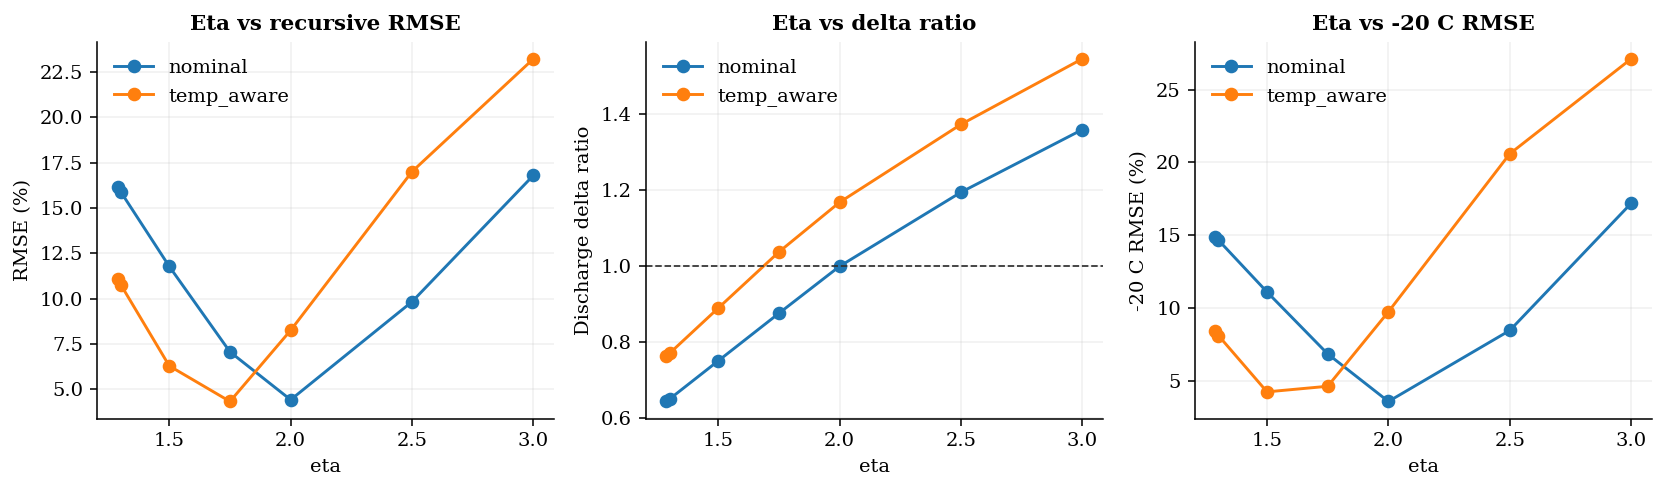

In [4]:
if not eta.empty:
    inf = eta[eta["mode"]=="inference_sweep"]
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
    for gm, df in inf.groupby("gamma_mode"):
        axes[0].plot(df["eta"], df["rec_rmse_pct"], marker="o", label=gm)
        axes[1].plot(df["eta"], df["rec_delta_ratio"], marker="o", label=gm)
        axes[2].plot(df["eta"], df["rec_rmse_n20"], marker="o", label=gm)
    axes[0].set_title("Eta vs recursive RMSE"); axes[0].set_ylabel("RMSE (%)")
    axes[1].axhline(1.0, color="#333", linestyle="--", linewidth=0.9); axes[1].set_title("Eta vs delta ratio"); axes[1].set_ylabel("Discharge delta ratio")
    axes[2].set_title("Eta vs -20 C RMSE"); axes[2].set_ylabel("-20 C RMSE (%)")
    for ax in axes:
        ax.set_xlabel("eta"); ax.legend()
    plt.tight_layout(); plt.show()


### Retraining checks

,mode,eta,gamma_mode,rec_delta_ratio,rec_rmse_pct,rec_rmse_n20,win_rmse_pct,mag_sat_high_pct,mag_sat_low_pct
14,retrained_eta1.287,1.287,nominal,0.5517,17.6226,12.8763,11.0034,34.027,43.835
15,retrained_eta2,2.000,nominal,1.1797,14.9136,18.9128,11.0405,55.436,14.709


Retraining at eta* does not self-calibrate cleanly; inference-time calibration is the observed rate-recovery mechanism.

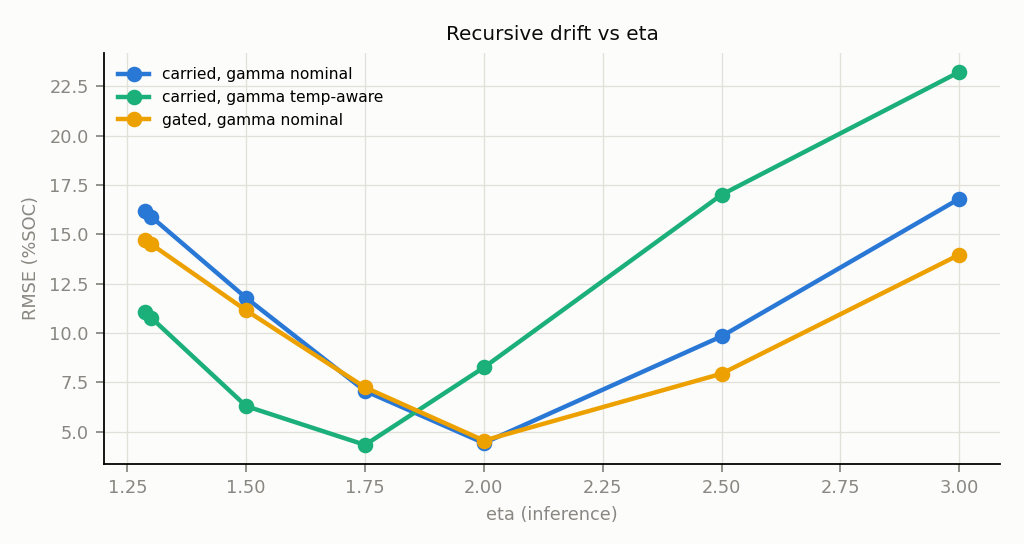

In [5]:
if not eta.empty:
    retrained = eta[eta["mode"].astype(str).str.contains("retrained", na=False)]
    if not retrained.empty:
        display(Markdown("### Retraining checks"))
        display(retrained[["mode","eta","gamma_mode","rec_delta_ratio","rec_rmse_pct","rec_rmse_n20","win_rmse_pct","mag_sat_high_pct","mag_sat_low_pct"]].round(4))
        display(Markdown("Retraining at eta* does not self-calibrate cleanly; inference-time calibration is the observed rate-recovery mechanism."))
maybe_display_png("results/v5/figures/eta_vs_recursive_drift.png")


## Interpretation

Fixed weights trained at eta=1.5 under-integrated the delta path. Inference envelope calibration at eta*=2.0 restores rate fidelity and collapses recursive error.

## Reviewer-risk note

Eta*=2.0 is strong evidence but currently single-checkpoint/single-scenario for the calibration sweep. Quote it conservatively.

## Final conclusion

Retraining does not self-calibrate; inference envelope calibration fixes delta-path underestimation.


In [6]:
show_missing()


### Missing artifacts recorded by this notebook: none

## Publication asset export (PUBLICATION_ASSET_EXPORT_V1)

This cell exports manuscript-ready figures/tables from existing v5 CSV/JSON artifacts only. It does not run training or alter experiment results.


In [7]:
# PUBLICATION_ASSET_EXPORT_V1
from pathlib import Path
import sys
EXPORT_DIR = Path('notebooks/ablation_studies_v5_final').resolve()
if str(EXPORT_DIR) not in sys.path:
    sys.path.insert(0, str(EXPORT_DIR))
from publication_asset_exports import export_for_notebook
validation = export_for_notebook('17')
print('publication assets refreshed:', validation['png_present'], 'figures and', validation['csv_present'], 'tables')


publication assets refreshed: 7 figures and 7 tables
